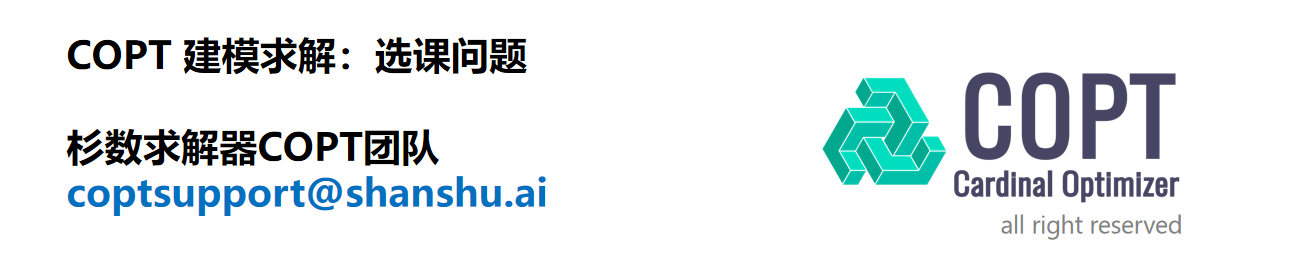

> **在线运行说明。** 下一格安装 `coptpy`。内置的免费许可有规模上限，但足够跑通本案例。然后执行「运行所有」。


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy


# 选课问题代码实现
## 建模求解MIP问题步骤

首先我们梳理一下，在Python中调用COPT对MIP问题进行建模和求解的基本步骤：

1. 导入 `coptpy` 包

2. 针对抽象模型，添加/导入模型测试**数据**

3. 创建**求解环境**和求解**模型**

4. 构建模型，依次添加**模型三要素**

- 添加**决策变量**：整数型（或0-1型）以及连续型
- 设置**目标函数**
- 添加**约束条件**

5. 设置**求解参数**并**求解**

6. 查看和分析求解**结果**


## 创建求解环境和求解模型

这是在Python中调用COPT建模和求解前必备的步骤：

In [1]:
from coptpy import *
# Create environment
env = Envr()

# Create model 
model = env.createModel(name="course_scheduling")

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## 添加测试数据
**1. 字典：key（课程，教师），
value 评分和时间段**

In [3]:
instructor, instructorRating, instructorTime = multidict({
    ('MGT 490', 1): [4.3, [('Mon', 4)]],
    ('MGT 490', 2): [3.8, [('Tues', 4)]],
    ('MGT 490', 3): [3.5, [('Wed', 4)]],
    ('MGT 490', 4): [3.5, [('Fri', 4)]],
    ('MGT 490', 5): [4.6, [('Mon', 1), ('Wed', 2)]],
    ('MGT 490', 6): [2.7, [('Tues', 2), ('Thur', 1)]],
    ('FIN 358', 1): [3.5, [('Wed', 4)]],
    ('FIN 358', 2): [3.3, [('Tues', 2), ('Thur', 1)]],
    ('CIS 102T', 1): [4.4, [('Wed', 3)]],
    ('CIS 102T', 2): [3.1, [('Thur', 3)]],
    ('CIS 102W', 1): [3.7, [('Tues', 4)]],
    ('CIS 102W', 2): [3.5, [('Wed', 3)]],
    ('FIN 325', 1): [3.0, [('Thur', 4)]],
    ('FIN 325', 2): [3.7, [('Mon', 1), ('Wed', 2)]],
    ('FIN 352', 1): [3.6, [('Mon', 4)]],
    ('FIN 352', 2): [3.9, [('Mon', 2), ('Wed', 1)]],
    ('FIN 356', 1): [3.2, [('Tues', 4)]],
    ('FIN 356', 2): [3.4, [('Tues', 2), ('Thur', 1)]],
    ('FIN 359', 1): [3.0, [('Mon', 4)]],
    ('FIN 359', 2): [3.5, [('Wed', 4)]],
}) 

**<big><font color="#3c70c6">小贴士</font></big>**

这里我们用到了辅助函数``multidict(data)``，它的作用是将输入的字典对象``data``拆分成键和多个新的字典对象并返回；

其中：``instructor``是拆分后的``key``，``instructorRating``和``instructorTime``新的字典对象，分别表示课程评分和课程时间段。

**2. 课程列表**

这里添加了4个列表对象，分别表示不同类型的课程。

In [5]:
compulsoryCourse = ['MGT 490', 'FIN 358']
cisOptionalCourse = ['CIS 102T', 'CIS 102W']
finOptionalCourse = ['FIN 325', 'FIN 352', 'FIN 356', 'FIN 359']
optionalCourse = cisOptionalCourse + finOptionalCourse

**3. 反向字典：key （星期，时间段）， value（课程，教师）**

为了便于添加关于时间段限制的约束，与之前的字典对象对应，这里我们再创建一个“反向字典”，``key``是（星期，时间段）构成的二元组，而``value``则为（课程，教师）。

这样在后续添加约束时，就可以方便地通过遍历时间段来依次定位到课程了。

In [7]:
weekdays = ['Mon', 'Tues', 'Wed', 'Thur', 'Fri']
timeInstructor = dict()
for w in weekdays:
    for j in [1,2,3,4]:
        timeInstructor[(w, j)] = []
for i in instructor:
    for t in instructorTime[i]:
        timeInstructor[t].append(i)

## 添加模型三要素

**添加决策变量**

这里批量添加决策变量：``instructor``表示变量的下标，是由（课程编号，教师编号）构成的``tuple``，指定变量类型``vtype=COPT.BINARY``，添加0-1决策变量``x``。


In [9]:
x = model.addVars(instructor, vtype=COPT.BINARY)

**设置目标函数**

设置目标函数为所选课程的总评分，``sense`` 指定优化方向为``COPT.MAXIMIZE`` 。

In [11]:
model.setObjective(quicksum(instructorRating[i] * x[i] for i in instructor), sense=COPT.MAXIMIZE)

**添加约束条件**

这里依次添加了在建模时分析的列出的6种约束条件，分别是：


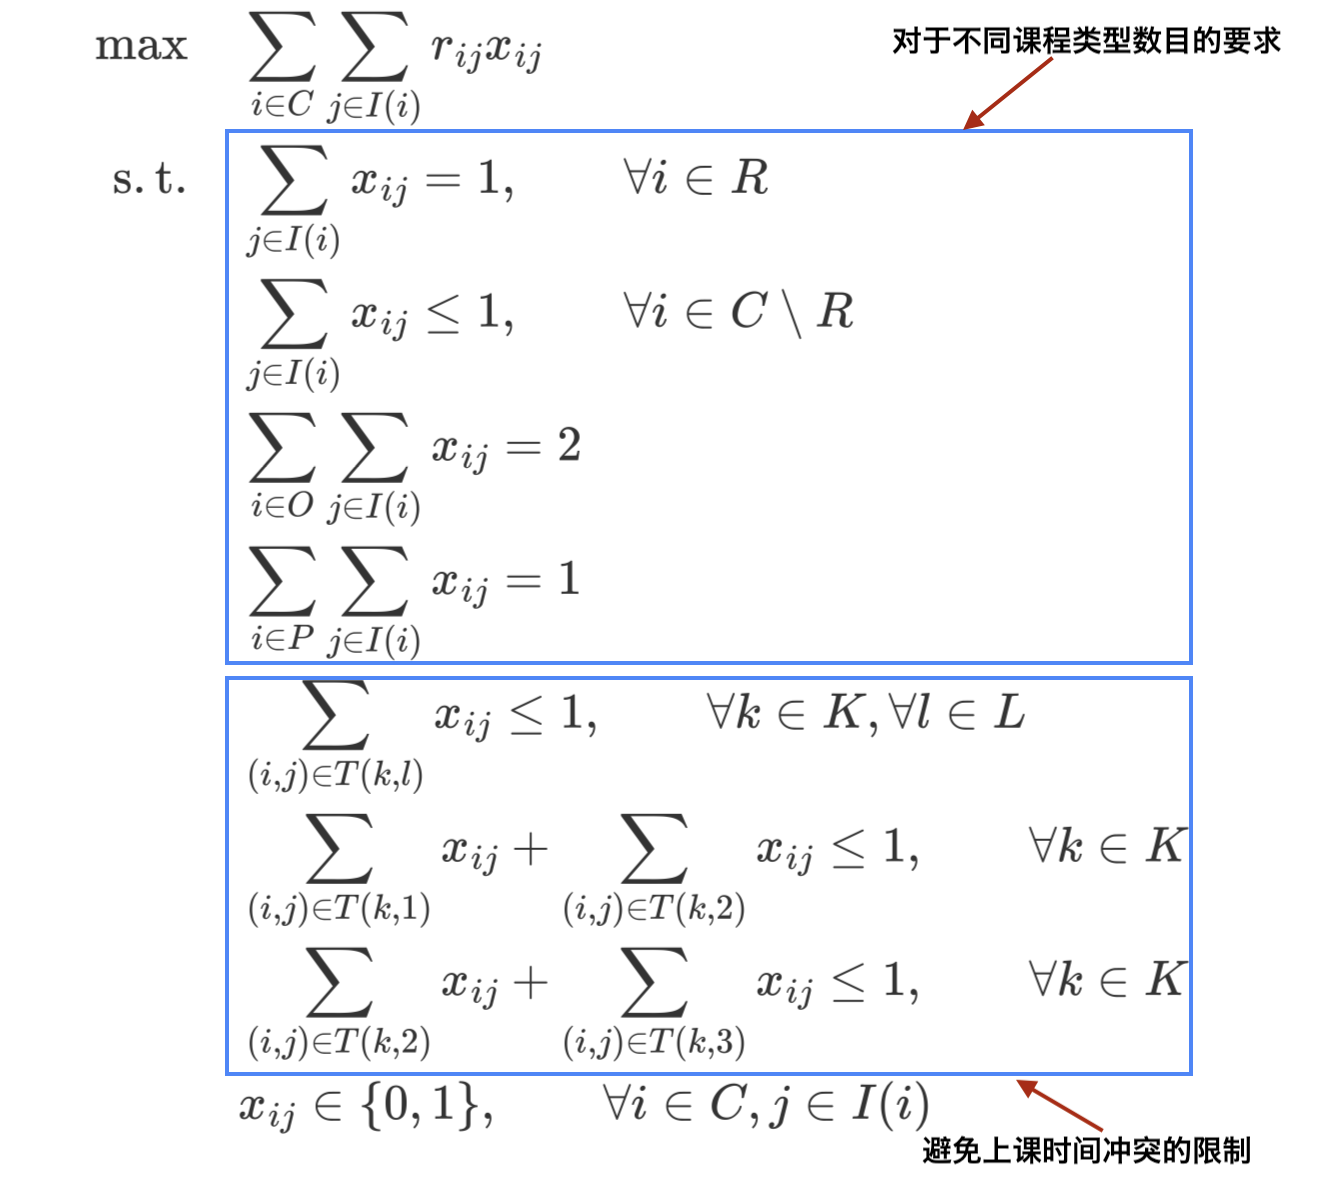

- 添加对于不同课程类型数目要求的约束：

In [13]:
model.addConstrs(quicksum(x[i] for i in instructor if i[0] == c) == 1 for c in compulsoryCourse)
model.addConstrs(quicksum(x[i] for i in instructor if i[0] == c) <= 1 for c in optionalCourse) 
model.addConstr(quicksum(x[i] for i in instructor for c in cisOptionalCourse if i[0] == c) == 1)
model.addConstr(quicksum(x[i] for i in instructor for c in finOptionalCourse if i[0] == c) == 2)
print("当前模型中约束数量：{}".format(model.getAttr("Rows")))

当前模型中约束数量：10


- 添加避免时间段冲突限制的约束：

In [15]:
model.addConstrs(quicksum(x[i] for i in timeInstructor[t]) <= 1 for t in timeInstructor.keys())
model.addConstrs(quicksum(x[i] for i in timeInstructor[(k,1)] + timeInstructor[(k,2)]) <= 1 for k in weekdays)
model.addConstrs(quicksum(x[i] for i in timeInstructor[(k,2)] + timeInstructor[(k,3)]) <= 1 for k in weekdays)
print("当前模型中约束数量：{}".format(model.getAttr("Rows")))

当前模型中约束数量：40


**<big><font color="#3c70c6">小贴士</font></big>**

**1. 推荐使用 ``quicksum()``：**

在构建线性和二次表达式时，``quicksum(data)``对求和过程进行了优化，比直接使用加号运算符在性能上会好很多，其中``data``为构成线性表达式中所有待加和的项；

**2. 批量添加的建模方式：**
- 这里建模时我们用到了**批量添加决策变量**的 ``Model.addVars(instructor)``，提供变量的下标为``instructor``；
- **批量添加约束**用到 ``Model.addConstrs(generator)`` ，其中``generator``为一个循环结构，其中每一项都是待添加的约束。

## 求解与获取结果

建模完成后，调用 ``Model.solve()`` 函数进行求解。

In [17]:
# Solve the model
model.solve()

Model fingerprint: e28dc7e9

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Maximizing a MIP problem

The original problem has:
    40 rows, 20 columns and 79 non-zero elements
    20 binaries

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    12 rows, 13 columns and 35 non-zero elements
    13 binaries

Problem info:
    Range of matrix coefficients:    [1e+00,1e+00]
    Range of rhs coefficients:       [1e+00,2e+00]
    Range of bound coefficients:     [1e+00,1e+00]
    Range of cost coefficients:      [3e-01,4e+00]
    Density of cost:                     100.0%

     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0         1      --       0  4.130000e+01            --     Inf  0.06s
H        0         1      --       0  4

最后，根据模型的求解结果，我们可以将选择得到的课程表（及时间段与评分）打印出来：

In [19]:
# Time mapping
timeCode = {
    1: "1:25-2:20 p.m.",
    2: "1:25-3:15 p.m.",
    3: "2:30-5:15 p.m.",
    4: "6:00-8:45 p.m."
}
# Get results
if model.status == COPT.OPTIMAL:
    print("Optimal Objective (Total Course Rating) : {:4f}".format(model.objval) )
    print("-"*58)
    print("|     course\t |     rating\t |         time\t\t |")
    for i in instructor:
        if x[i].x >= 1e-6:
            timeList = instructorTime[i]
            print("-"*58)
            print("|    {0}\t |      {1}\t | {2}  {3}\t |".format(i[0], instructorRating[i], timeList[0][0], timeCode[timeList[0][1]]))
            if len(timeList) > 1:
                print("|\t\t |\t\t | {2}  {3}\t |".format(i[0], instructorRating[i], timeList[1][0], timeCode[timeList[1][1]]))
    print("-"*58)

Optimal Objective (Total Course Rating) : 19.500000
----------------------------------------------------------
|     course	 |     rating	 |         time		 |
----------------------------------------------------------
|    MGT 490	 |      4.3	 | Mon  6:00-8:45 p.m.	 |
----------------------------------------------------------
|    FIN 358	 |      3.5	 | Wed  6:00-8:45 p.m.	 |
----------------------------------------------------------
|    CIS 102T	 |      4.4	 | Wed  2:30-5:15 p.m.	 |
----------------------------------------------------------
|    FIN 352	 |      3.9	 | Mon  1:25-3:15 p.m.	 |
|		 |		 | Wed  1:25-2:20 p.m.	 |
----------------------------------------------------------
|    FIN 356	 |      3.4	 | Tues  1:25-3:15 p.m.	 |
|		 |		 | Thur  1:25-2:20 p.m.	 |
----------------------------------------------------------


**<big><font color="#3c70c6">小贴士</font></big>**

通过访问``Model``类的成员属性，可以直接获取求解结果（其中属性名称与大小写无关）：
- ``model.status``：获取模型求解状态
- ``model.objval``：获取目标函数最优值
- ``model.x``：获取决策变量取值

# 参考资料
[1] Janice K. Winch, Jack Yurkiewicz (2014) Case—Kelly’s Class Scheduling. INFORMS Transactions on Education 15(1):148-149.
http://dx.doi.org/10.1287/ited.2014.0128cs